In [2]:
%matplotlib inline

Use z-stacks with ImageContainer
================================
In this example we showcase how to use z-stacks with {class}`squidpy.im.ImageContainer`

It is possible to acquire several consecutive image slices from the same tissue.
Squidpy's `ImageContainer` supports storing, processing, and visualization of these z-stacks.

Here, we use the Visium 10x mouse brain sagittal slices as an example of a z-stack image with two Z dimensions.
We will use the "hires" images contained in the {class}`anndata.AnnData` object, but you could also use the
original resolution tiff images in the `ImageContainer`.


Import libraries and load individual image sections
---------------------------------------------------

In [3]:
import anndata as ad
import scanpy as sc
import squidpy as sq

library_ids = [
    "V1_Mouse_Brain_Sagittal_Posterior",
    "V1_Mouse_Brain_Sagittal_Posterior_Section_2",
]

adatas, imgs = [], []
use_hires_tiff = False
for library_id in library_ids:
    adatas.append(sc.datasets.visium_sge(library_id, include_hires_tiff=use_hires_tiff))
    adatas[-1].var_names_make_unique()
    if use_hires_tiff:
        imgs.append(
            sq.im.ImageContainer(
                adatas[-1].uns["spatial"][library_id]["metadata"]["source_image_path"]
            )
        )
    else:
        # as we are using a scaled image, we need to specify a scalefactor
        # to allow correct mapping to adata.obsm['spatial']
        imgs.append(
            sq.im.ImageContainer(
                adatas[-1].uns["spatial"][library_id]["images"]["hires"],
                scale=adatas[-1].uns["spatial"][library_id]["scalefactors"][
                    "tissue_hires_scalef"
                ],
            )
        )

100%|██████████| 9.26M/9.26M [00:01<00:00, 4.96MB/s]
100%|██████████| 20.1M/20.1M [00:05<00:00, 3.57MB/s]
100%|██████████| 9.26M/9.26M [00:01<00:00, 5.00MB/s]
100%|██████████| 19.0M/19.0M [00:04<00:00, 4.66MB/s]


Concatenate per-section data to a z-stack
-----------------------------------------
To allow mapping from observations in `adata` to the correct Z dimension in `img`,
we will store a ``library_id`` column in ``adata.obs`` and associate each ``library_id``
to a Z dimension in the `ImageContainer`.

For this, we will use {func}`anndata.concat` with ``uns_merge = only``
(to ensure that `uns` entries are correctly concatenated),
``label = 'library_id'`` and ``keys = library_ids`` (to create the necessary column in ``adata.obs``.

To concatenate the individual {class}`squidpy.im.ImageContainer`,
we will use {meth}`squidpy.im.ImageContainer.concat`, specifying
``library_ids = library_ids`` for associating each image with the correct observations in `adata`.

In [4]:
adata = ad.concat(
    adatas, uns_merge="only", label="library_id", keys=library_ids, index_unique="-"
)
img = sq.im.ImageContainer.concat(imgs, library_ids=library_ids)

`adata` now contains a ``library_id`` column in ``adata.obs``, which maps observations to a unique `library_id`.

In [5]:
print(adata)
adata.obs

AnnData object with n_obs × n_vars = 6644 × 32285
    obs: 'in_tissue', 'array_row', 'array_col', 'library_id'
    uns: 'spatial'
    obsm: 'spatial'


,in_tissue,array_row,array_col,library_id
AAACAAGTATCTCCCA-1-V1_Mouse_Brain_Sagittal_Posterior,1,50,102,V1_Mouse_Brain_Sagittal_Posterior
AAACACCAATAACTGC-1-V1_Mouse_Brain_Sagittal_Posterior,1,59,19,V1_Mouse_Brain_Sagittal_Posterior
AAACAGAGCGACTCCT-1-V1_Mouse_Brain_Sagittal_Posterior,1,14,94,V1_Mouse_Brain_Sagittal_Posterior
AAACAGCTTTCAGAAG-1-V1_Mouse_Brain_Sagittal_Posterior,1,43,9,V1_Mouse_Brain_Sagittal_Posterior
AAACAGGGTCTATATT-1-V1_Mouse_Brain_Sagittal_Posterior,1,47,13,V1_Mouse_Brain_Sagittal_Posterior
...,...,...,...,...
TTGTTGTGTGTCAAGA-1-V1_Mouse_Brain_Sagittal_Posterior_Section_2,1,31,77,V1_Mouse_Brain_Sagittal_Posterior_Section_2
TTGTTTCACATCCAGG-1-V1_Mouse_Brain_Sagittal_Posterior_Section_2,1,58,42,V1_Mouse_Brain_Sagittal_Posterior_Section_2
TTGTTTCATTAGTCTA-1-V1_Mouse_Brain_Sagittal_Posterior_Section_2,1,60,30,V1_Mouse_Brain_Sagittal_Posterior_Section_2
TTGTTTCCATACAACT-1-V1_Mouse_Brain_Sagittal_Posterior_Section_2,1,45,27,V1_Mouse_Brain_Sagittal_Posterior_Section_2


`img` contains the 2D images concatenated along the Z dimension in one image layer.
The Z dimensions are named the same as the `library_id`'s in `adata` to allow a mapping from `adata` to `img`.

In [6]:
print(img["image"].z)
img

<xarray.DataArray 'z' (z: 2)>
array(['V1_Mouse_Brain_Sagittal_Posterior',
       'V1_Mouse_Brain_Sagittal_Posterior_Section_2'], dtype='<U43')
Coordinates:
  * z        (z) <U43 'V1_Mouse_Brain_Sagittal_Posterior' 'V1_Mouse_Brain_Sag...


ImageContainer[shape=(1998, 2000), layers=['image']]

It is also possible to initialize the `ImageContainer` with images that already contain the Z dimension.
In this case you need to specify the ``library_id`` argument in the constructor.
In addition, you might want to set ``dims`` to the correct ordering of dimensions manually for more control.

In [7]:
arr = img["image"].values
print(arr.shape)
img2 = sq.im.ImageContainer(
    arr, library_id=library_ids, dims=("y", "x", "z", "channels")
)
img2

(1998, 2000, 2, 3)


ImageContainer[shape=(1998, 2000), layers=['image']]

Generally, an `ImageContainer` with more than one Z dimension can be used in the same way as an `ImageContainer`
with only one Z dimension.
In addition, we can specify `library_id` to cropping, pre-processing,
and segmentation functions if we'd like to only process a specific `library_id`.

Visualization
-------------
For using {func}`squidpy.pl.spatial_scatter`, subset the `adata` to the desired `library_id`.

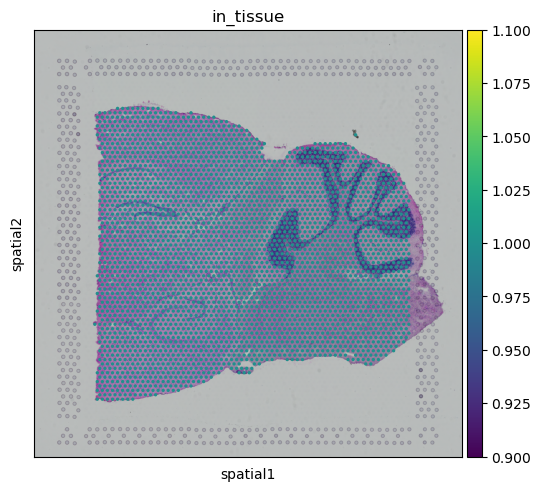

In [8]:
library_id = library_ids[0]
sq.pl.spatial_scatter(
    adata[adata.obs["library_id"] == library_id],
    library_id=library_id,
    color="in_tissue",
)

{meth}`squidpy.im.ImageContainer.show` works with z-stacks out of the box, by plotting them as separate images.
Additionally, you can specify a `library_id` if you only want to plot one Z dimension.

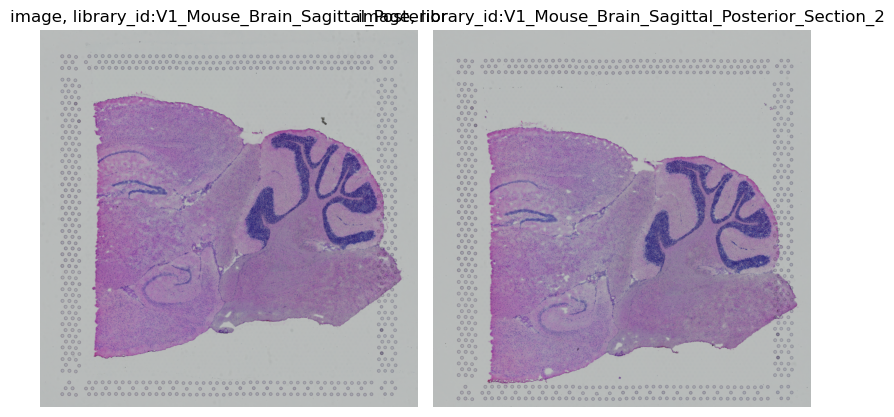

In [9]:
img.show()

For interactive visualization with napari, please use [napari-spatialdata](https://github.com/scverse/napari-spatialdata).
See the [napari-spatialdata documentation](https://spatialdata.scverse.org/projects/napari/en/stable/notebooks/spatialdata.html) for examples.

Cropping
--------
By default, the cropping functions will crop all Z dimensions.

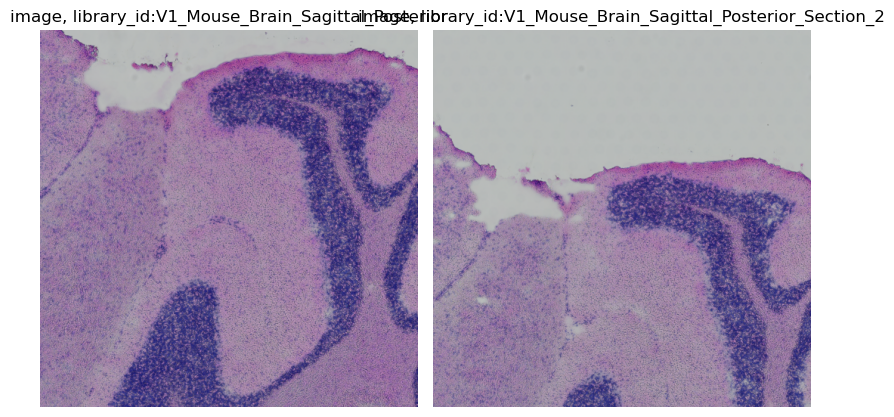

In [10]:
crop = img.crop_corner(500, 1000, size=500)
crop.show()

You can also specify ``library_id``, as either a single or multiple Z dimensions to crop.

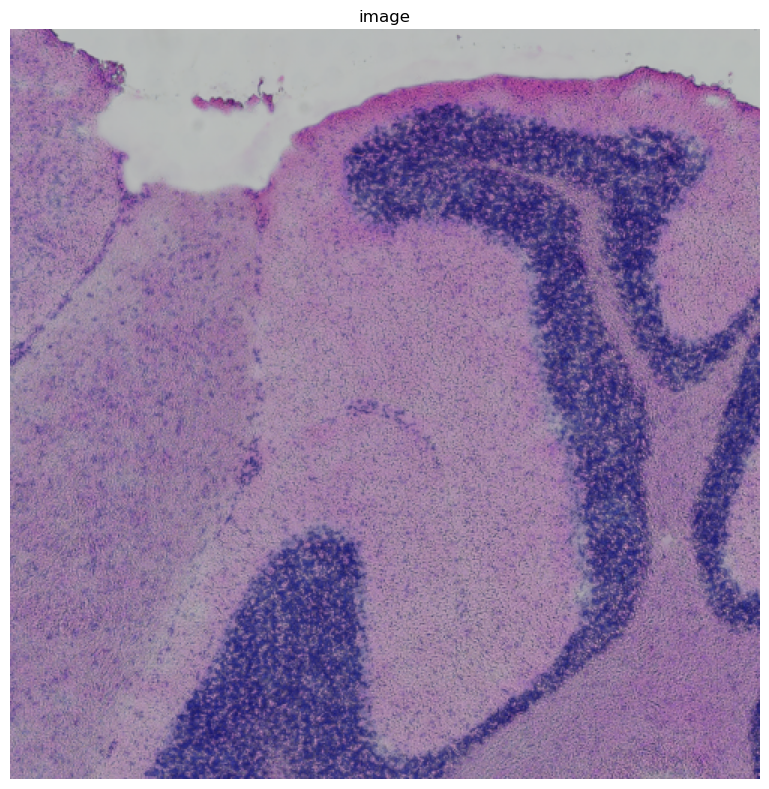

In [11]:
img.crop_corner(500, 1000, size=500, library_id=library_ids[0]).show()

Processing and segmenting
-------------------------
Let us smooth the image.
When not specifying a `library_id`, {func}`squidpy.im.process` treats the image as a 3D volume.
As we would like to smooth only in x and y dimensions, and not in z, we need so specify a per-dimension `sigma`.
The internal dimensions of the image are ``y, x, z, channels``, as you can check with ``crop['image'].dims``.
Therefore, to only smooth in x and y, we need to specify ``sigma = [10, 10, 0, 0]``.

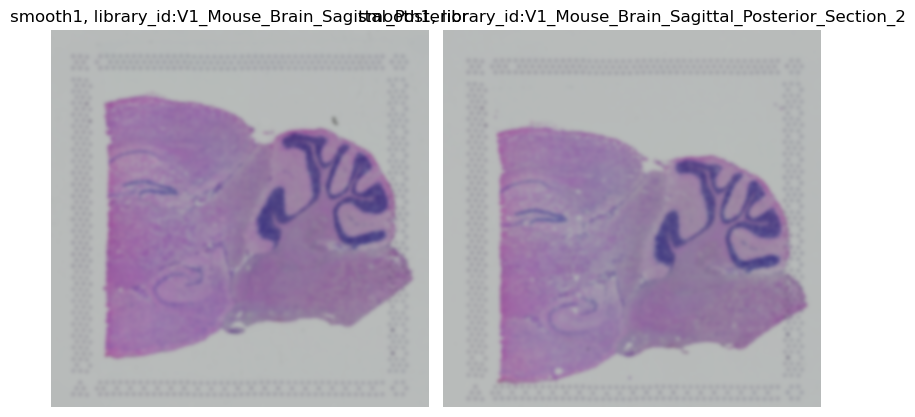

In [12]:
sq.im.process(
    img, layer="image", method="smooth", sigma=[10, 10, 0, 0], layer_added="smooth1"
)
img.show("smooth1")

Now, let us just smooth one `library_id`.
Specifying `library_id` means that the processing function will process each Z dimension separately.
This means that now the dimensions of the processed image are ``y, x, channels`` (with ``z`` removed), meaning that
we have to update `sigma` accordingly.
If the number of channels does not change due to the processing, {func}`squidpy.im.process` implies the identity
function for non-processed Z dimensions.

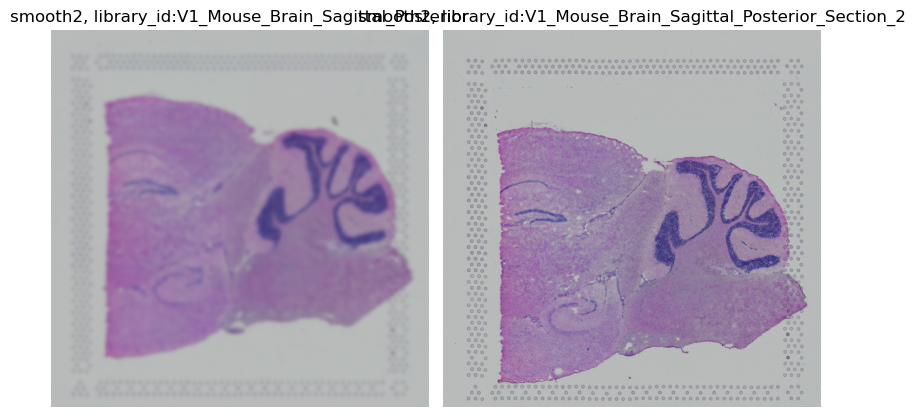

In [13]:
sq.im.process(
    img,
    layer="image",
    method="smooth",
    sigma=10,
    layer_added="smooth2",
    library_id=library_ids[0],
)
img.show("smooth2")

None, only the first `library_id` is smoothed.
For the second, the original image was used.

If the processing function changes the number of dimensions, non-processed Z dimensions will contain 0.
Let's see this behavior with using ``method = 'gray'``, which moves from 3 channels (RGB) to one channel (gray).

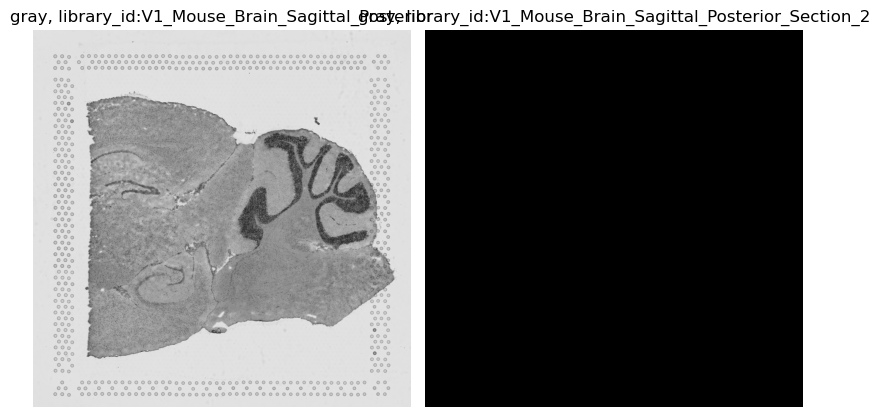

In [14]:
sq.im.process(
    img, layer="image", method="gray", layer_added="gray", library_id=library_ids[0]
)
img.show("gray", cmap="gray")

{func}`squidpy.im.segment` works in the same way, just specify `library_id` if you only wish to
segment specific Z dimensions.

Feature calculation
-------------------
Calculating features from z-stack images is straight forward as well.
With more than one Z dimension, we just need to specify the column name in ``adata.obs``
which contains the mapping from observations to `library_ids`
to allow the function to extract the features from the correct Z dimension.
As of now, features can only be extracted on 2D, meaning from the Z dimension that the current spot is located on.

The following call extracts features for each observation in `adata`, automatically choosing the correct
Z dimension in `img`.

In [15]:
adata_crop = crop.subset(adata)  # subset adata to the image crop
sq.im.calculate_image_features(
    adata_crop,
    crop,
    library_id="library_id",
    layer="image",
    features="summary",
    n_jobs=4,
)
adata_crop.obsm["img_features"]

100%|██████████| 774/774 [00:14<00:00, 54.34/s] 


,summary_ch-0_quantile-0.9,summary_ch-0_quantile-0.5,summary_ch-0_quantile-0.1,summary_ch-0_mean,summary_ch-0_std,summary_ch-1_quantile-0.9,summary_ch-1_quantile-0.5,summary_ch-1_quantile-0.1,summary_ch-1_mean,summary_ch-1_std,summary_ch-2_quantile-0.9,summary_ch-2_quantile-0.5,summary_ch-2_quantile-0.1,summary_ch-2_mean,summary_ch-2_std
AAACAGAGCGACTCCT-1-V1_Mouse_Brain_Sagittal_Posterior,0.721569,0.670588,0.542745,0.647495,0.074835,0.725490,0.611765,0.247059,0.517943,0.209248,0.729412,0.674510,0.549020,0.652933,0.074534
AAACGAGACGGTTGAT-1-V1_Mouse_Brain_Sagittal_Posterior,0.450980,0.309804,0.200000,0.317769,0.095004,0.360784,0.270588,0.184314,0.269996,0.069024,0.576471,0.509804,0.462745,0.515190,0.045777
AAATTACCTATCGATG-1-V1_Mouse_Brain_Sagittal_Posterior,0.680784,0.611765,0.487843,0.599930,0.075161,0.517647,0.462745,0.379608,0.455529,0.055273,0.692549,0.650980,0.596078,0.647303,0.041485
AACAGGAAATCGAATA-1-V1_Mouse_Brain_Sagittal_Posterior,0.658824,0.603922,0.511373,0.594231,0.057229,0.521569,0.466667,0.393725,0.462379,0.048675,0.678431,0.643137,0.584314,0.635939,0.035439
AACATATCAACTGGTG-1-V1_Mouse_Brain_Sagittal_Posterior,0.586667,0.360784,0.211765,0.385795,0.140289,0.447059,0.301961,0.185882,0.308392,0.098326,0.645490,0.533333,0.444706,0.540601,0.071795
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGGGACACTGCCCGC-1-V1_Mouse_Brain_Sagittal_Posterior_Section_2,0.635294,0.580392,0.480000,0.564357,0.063804,0.522353,0.466667,0.397647,0.464401,0.049290,0.674510,0.631373,0.580392,0.627468,0.038752
TTGGGCGGCGGTTGCC-1-V1_Mouse_Brain_Sagittal_Posterior_Section_2,0.643137,0.592157,0.502745,0.582867,0.055017,0.556863,0.505882,0.435294,0.500200,0.047835,0.666667,0.631373,0.581961,0.626580,0.033794
TTGTAAGGCCAGTTGG-1-V1_Mouse_Brain_Sagittal_Posterior_Section_2,0.670588,0.627451,0.537255,0.615948,0.055211,0.602353,0.556863,0.483922,0.548758,0.047661,0.694118,0.662745,0.596078,0.652636,0.036439
TTGTTCAGTGTGCTAC-1-V1_Mouse_Brain_Sagittal_Posterior_Section_2,0.647059,0.584314,0.476078,0.571329,0.064511,0.545098,0.494118,0.419608,0.489499,0.048448,0.674510,0.639216,0.592157,0.636148,0.032888


The calculated features can now be used in downstream Scanpy analyses, by e.g. using all Z dimensions
to cluster spots based on image features and gene features.

Here, we cluster genes and calculated features using a standard Scanpy workflow.

In [16]:
sc.pp.normalize_total(adata_crop, inplace=True)
sc.pp.log1p(adata_crop)
sc.pp.pca(adata_crop)
sc.pp.neighbors(adata_crop)
sc.tl.leiden(adata_crop)

sc.pp.neighbors(adata_crop, use_rep="img_features", key_added="neigh_features")
sc.tl.leiden(adata_crop, neighbors_key="neigh_features", key_added="leiden_features")

Visualize the result interactively using [napari-spatialdata](https://github.com/scverse/napari-spatialdata), or statically using {func}`squidpy.pl.spatial_scatter`:

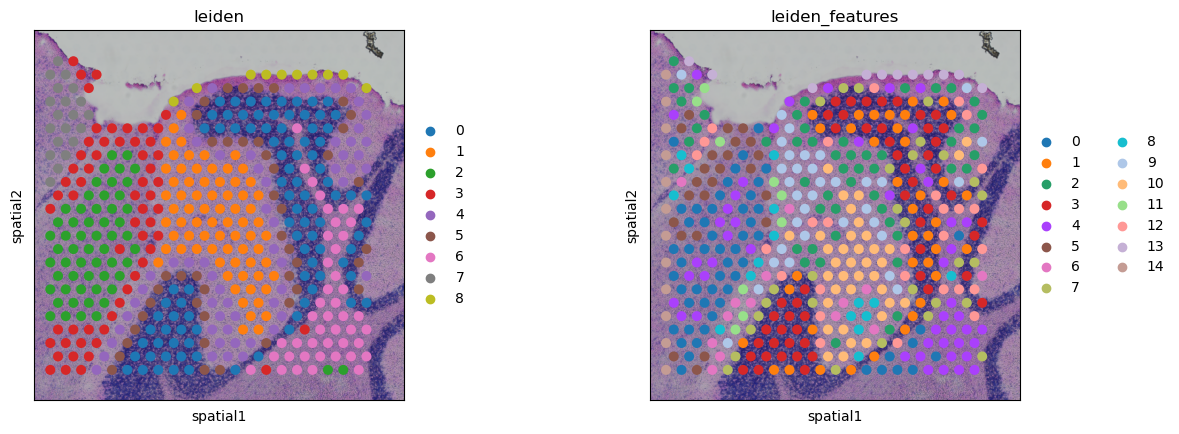

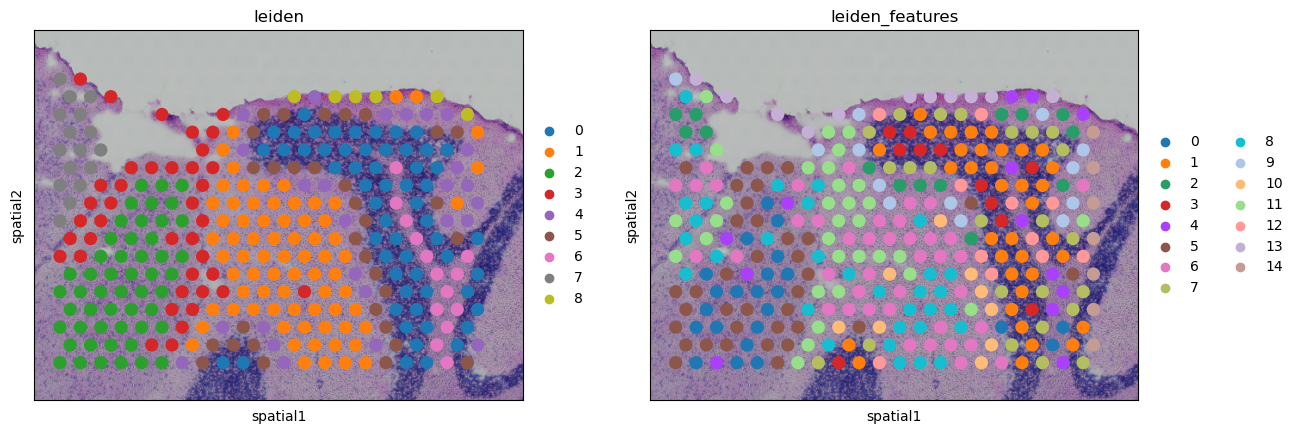

In [17]:
sq.pl.spatial_scatter(
    adata_crop,
    library_key="library_id",
    crop_coord=(5700, 2700, 9000, 6000),
    library_id=library_ids[0],
    color=["leiden", "leiden_features"],
)

sq.pl.spatial_scatter(
    adata_crop,
    library_key="library_id",
    crop_coord=(5700, 3500, 9000, 6000),
    library_id=library_ids[1],
    color=["leiden", "leiden_features"],
)